# EXPLOLATORY ANALYZES

## Reading the data

In [532]:
import pandas as pd
# Show all columns (no truncation)
pd.set_option('display.max_columns', None)

# Show all rows (use a number if you want a limit, e.g., 100)
pd.set_option('display.max_rows', None)

# Increase the width of the display to avoid line wrapping
pd.set_option('display.width', None)

# Align numbers to the right and format floats (e.g., amounts with 2 decimals)
pd.set_option('display.float_format', '{:.2f}'.format)

# Optional: display all columns on one line if screen is wide
pd.set_option('display.expand_frame_repr', False)

df = pd.read_csv('transactional-sample.csv')
df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.00,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.00,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.00,False


## 1.Basic data quality checks

### MISSING VALUES & DUPLICATES

#### Missing values

In [533]:
# Checking for MISSING VALUES
df.isnull().sum()

transaction_id          0
merchant_id             0
user_id                 0
card_number             0
transaction_date        0
transaction_amount      0
device_id             830
has_cbk                 0
dtype: int64

#### Duplicates

In [534]:
# Checking for Full_rows duplicates
df.duplicated().sum()

np.int64(0)

In [535]:
# Checking for duplicate transaction_id
df['transaction_id'].duplicated().sum()

np.int64(0)

In [536]:
# Checking for Near-Duplicates
df_nd = df.copy()
df_nd['transaction_date'] = pd.to_datetime(df_nd['transaction_date'])
df_nd = df.sort_values('transaction_date')

threshold = pd.Timedelta(minutes=2)

df_nd['time_diff'] = df_nd.groupby(['user_id', 'card_number', 'merchant_id', 'transaction_amount'])['transaction_date'].diff()
df_nd['is_near_duplicate'] = df_nd['time_diff'].notna() & (df_nd['time_diff'] <= threshold)

near_duplicates = df_nd[df_nd['is_near_duplicate']]
near_duplicates

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,time_diff,is_near_duplicate


### DATA TYPES

In [537]:
# Checking types
df.dtypes

transaction_id          int64
merchant_id             int64
user_id                 int64
card_number               str
transaction_date          str
transaction_amount    float64
device_id             float64
has_cbk                  bool
dtype: object

In [538]:
# Confirming the type of transaction_date and making sure the range makes sense
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
min_date = df['transaction_date'].min()

max_date = df['transaction_date'].max()
print(f"Data range:{min_date} to {max_date}")

Data range:2019-11-01 01:27:15.811098 to 2019-12-01 23:16:32.812632


In [539]:
# Checking for format consistency in card_number across all rows
expected_pattern = r'^\d{6}\*{6}\d{4}$'
df_valid_card_number = df.copy() 
df_valid_card_number['is_format_valid'] = df['card_number'].dropna().astype(str).str.match(expected_pattern, na=False)

print(df_valid_card_number['is_format_valid'].value_counts())
print(f"Invalid rows: {df_valid_card_number[~df_valid_card_number['is_format_valid']].shape[0]}")

is_format_valid
True     3160
False      39
Name: count, dtype: int64
Invalid rows: 39


### Range / sanity checks on transaction_amount

In [540]:
# Data from the column
df['transaction_amount'].describe()

count   3199.00
mean     767.81
std      889.10
min        1.22
25%      205.24
50%      415.94
75%      981.68
max     4097.21
Name: transaction_amount, dtype: float64

In [541]:
# Checking for negative amounts
df[df['transaction_amount'] < 0]

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk


In [542]:
# Checking for zero amounts
df[df['transaction_amount'] == 0]

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk


In [543]:
# Checking for extreme outliers (using IQR)

# Understanding the tail
percentiles = [0.90, 0.95, 0.99, 0.999, 0.9999]
for p in percentiles:
    value = df['transaction_amount'].quantile(p)
    print(f"Percentile {p*100:.2f}%: {value:.2f}")

# Checking the absolute maximum
print(f"Maximum value: {df['transaction_amount'].max():.2f}")

# Looking at the top 10 largest transactions
top_10 = df.nlargest(10, 'transaction_amount')[['transaction_id', 'transaction_amount']]
print(top_10)

Percentile 90.00%: 2074.93
Percentile 95.00%: 2775.27
Percentile 99.00%: 4028.55
Percentile 99.90%: 4089.85
Percentile 99.99%: 4096.77
Maximum value: 4097.21
      transaction_id  transaction_amount
2516        21322914             4097.21
1713        21322111             4095.82
2550        21322948             4091.83
2651        21323049             4089.88
1277        21321675             4089.73
920         21321318             4080.03
684         21321082             4078.80
1707        21322105             4077.47
2776        21323174             4077.07
1293        21321691             4076.40


In [544]:
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1

standard_upper_bound = Q3 + 1.5 * IQR
extreme_upper_bound = Q3 + 3.0 * IQR  # More aggressive for fraud

print(f"Standard IQR upper bound: {standard_upper_bound:.2f}")
print(f"Extreme IQR upper bound: {extreme_upper_bound:.2f}")

Standard IQR upper bound: 2146.35
Extreme IQR upper bound: 3311.02


In [545]:
# Option A: Statistical (Top 1%)
p99 = df['transaction_amount'].quantile(0.99)
df_IQR = df.copy()
df_IQR['is_amount_extreme'] = df_IQR['transaction_amount'] > p99

# Option B: Business Rule (e.g., anything over $10,000)
# df['is_amount_extreme'] = df['transaction_amount'] > 10000

# Count how many you flagged
print(f"Flagged {df_IQR['is_amount_extreme'].sum()} transactions as extreme outliers.")

Flagged 31 transactions as extreme outliers.


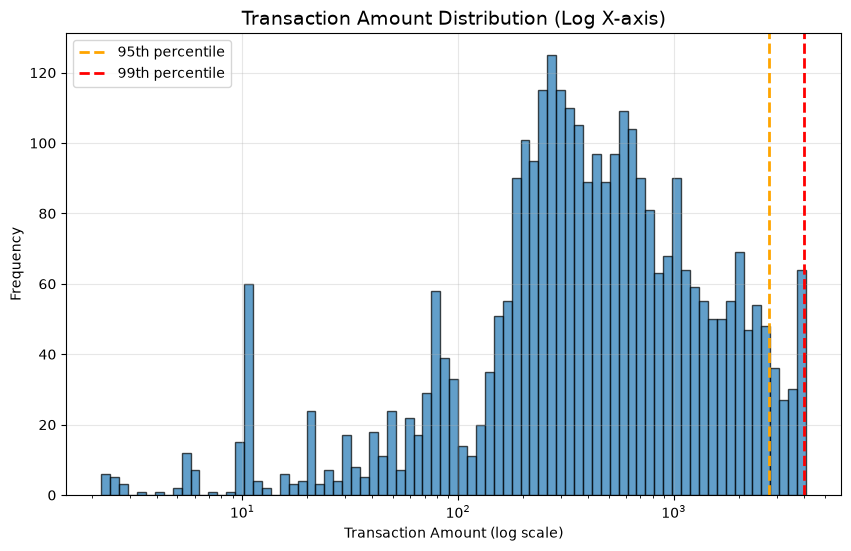

In [546]:
# Ploting a histogram to get a visual sense of the shape

import matplotlib.pyplot as plt
import numpy as np

log_bins = np.logspace(
    np.log10(df['transaction_amount'].min() + 1),
    np.log10(df['transaction_amount'].max() + 1),
    num=80
)

plt.figure(figsize=(10, 6))
plt.hist(df['transaction_amount'], bins=log_bins, edgecolor='black', alpha=0.7)

# Add percentile reference lines
plt.axvline(df['transaction_amount'].quantile(0.95), color='orange', linestyle='--', linewidth=2, label='95th percentile')
plt.axvline(df['transaction_amount'].quantile(0.99), color='red', linestyle='--', linewidth=2, label='99th percentile')

plt.xscale('log')

plt.title('Transaction Amount Distribution (Log X-axis)', fontsize=14)
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Overall has_cbk rate (class imbalance)

In [547]:
df['has_cbk'].value_counts(normalize=True)

has_cbk
False   0.88
True    0.12
Name: proportion, dtype: float64

## 2.Univariate analysis of has_cbk

### By merchant_id

In [548]:
df_merchant = df.copy()
df_merchant = df_merchant.groupby('merchant_id')['has_cbk'].agg(number_of_transactions='count', rate='mean').reset_index()
df_merchant[df_merchant['number_of_transactions']>10].sort_values('rate')

,merchant_id,number_of_transactions,rate
66,4129,14,0.00
510,26981,16,0.00
508,26765,18,0.00
341,17348,16,0.00
896,49205,73,0.00
777,42178,15,0.00
679,36929,13,0.00
561,29931,12,0.00
1648,93881,11,0.00
1746,99379,11,0.00


### By user_id

In [549]:
df_user_id = df.copy()
df_user_id = df_user_id.groupby('user_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_user_id[df_user_id['number_of_transactions']>10].sort_values('rate')

,number_of_transactions,rate
user_id,,
11750,31,0.81
91637,22,0.86
79054,17,0.88
78262,13,0.92
96025,14,0.93


### By device_id

In [550]:
df_device_id = df.copy()
df_device_id = df_device_id.groupby('device_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_device_id = df_device_id[df_device_id['number_of_transactions']>10].sort_values('rate').reset_index()
df_numb_users = df.groupby('device_id')['user_id'].agg(number_of_users = 'nunique').reset_index()
print(f"Devices with more than one user:\n{df_numb_users[df_numb_users['number_of_users']>1]} \nRate of devices with more than 10 transactions:\n{df_device_id}")

Devices with more than one user:
Empty DataFrame
Columns: [device_id, number_of_users]
Index: [] 
Rate of devices with more than 10 transactions:
   device_id  number_of_transactions  rate
0  342890.00                      19  0.79
1  563499.00                      22  0.86
2  101848.00                      17  0.88
3  547440.00                      13  0.92
4  438940.00                      14  0.93


### By card_number

In [551]:
df_card_number = df.copy()
df_card_number = df_card_number.groupby('device_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_card_number = df_card_number[df_card_number['number_of_transactions']>10].sort_values('rate')
df_numb_devices = df.groupby('card_number')['device_id'].agg(number_of_devices = 'nunique').reset_index()
df_numb_users_card = df.groupby('card_number')['user_id'].agg(number_of_users = 'nunique').reset_index()
print(f"Cards with more than 2 devices:\n{df_numb_devices[df_numb_devices['number_of_devices']>2]}\nCards with more than 2 users:\n{df_numb_users_card[df_numb_users_card['number_of_users']>2]} \nRate of cards with more than 10 transactions:\n{df_card_number}")

Cards with more than 2 devices:
          card_number  number_of_devices
876  496045******1160                  4
Cards with more than 2 users:
           card_number  number_of_users
876   496045******1160                4
2493  550209******6420                3 
Rate of cards with more than 10 transactions:
           number_of_transactions  rate
device_id                              
342890.00                      19  0.79
563499.00                      22  0.86
101848.00                      17  0.88
547440.00                      13  0.92
438940.00                      14  0.93


## 3. Transaction amount patterns

### 1. Distribution comparison: fraud vs. non-fraud

In [552]:
df.groupby('has_cbk')['transaction_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
has_cbk,,,,,,,,
False,2808.00,672.32,797.46,1.22,191.28,360.31,812.58,4091.83
True,391.00,1453.57,1169.49,2.89,565.58,999.47,2140.68,4097.21


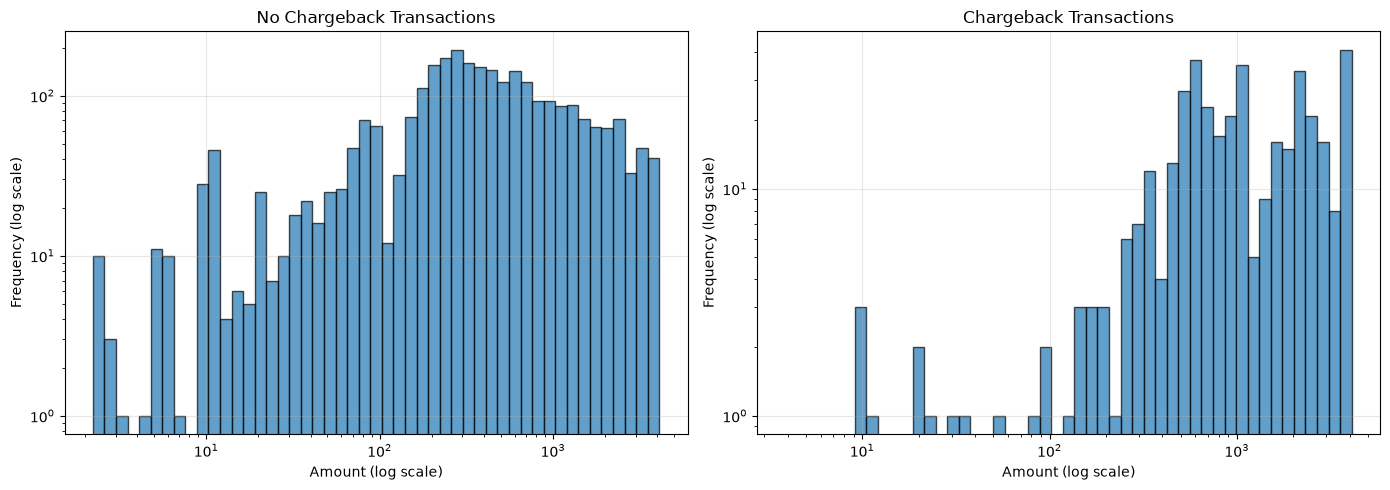

<Figure size 800x600 with 0 Axes>

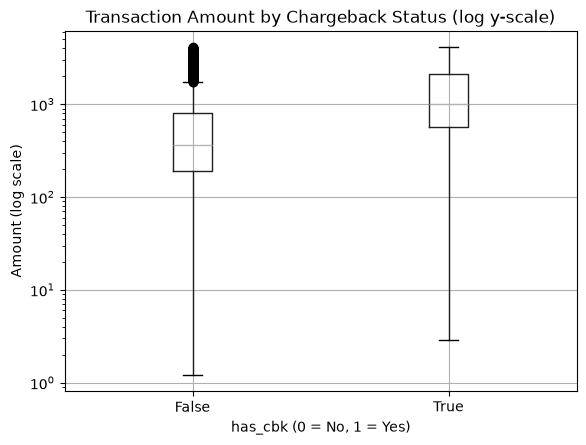

In [553]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale on X
for ax, cbk_val, label in zip(axes, [0, 1], ['No Chargeback', 'Chargeback']):
    subset = df[df['has_cbk'] == cbk_val]['transaction_amount'].dropna()
    ax.hist(subset, bins=np.logspace(np.log10(subset.min()+1), np.log10(subset.max()+1), 50), 
            alpha=0.7, edgecolor='black', log=True)
    ax.set_xscale('log')
    ax.set_title(f'{label} Transactions')
    ax.set_xlabel('Amount (log scale)')
    ax.set_ylabel('Frequency (log scale)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8, 6))
df.boxplot(column='transaction_amount', by='has_cbk', grid=True, vert=True, showfliers=True)
plt.yscale('log')
plt.title('Transaction Amount by Chargeback Status (log y-scale)')
plt.suptitle('')
plt.ylabel('Amount (log scale)')
plt.xlabel('has_cbk (0 = No, 1 = Yes)')
plt.show()

### 2. Round numbers / suspiciously repeated amounts

In [574]:
df_ta_cd = df.groupby(['transaction_amount', 'card_number']).size().reset_index(name = 'number_of_transactions')
df_ta_ui = df.groupby(['transaction_amount', 'user_id']).size().reset_index(name = 'number_of_transactions')
print(f"Number of transactions with the same transaction amount and card number/user id :\n{df_ta_cd[df_ta_cd['number_of_transactions']>1]}\n{df_ta_ui[df_ta_ui['number_of_transactions']>1]}")

Number of transactions with the same transaction amount and card number/user id :
Empty DataFrame
Columns: [transaction_amount, card_number, number_of_transactions]
Index: []
Empty DataFrame
Columns: [transaction_amount, user_id, number_of_transactions]
Index: []


### 3. Small/zero amount "card testing" pattern

In [555]:
df_card_testing = df.copy()
df_card_testing = df_card_testing.sort_values(['card_number', 'transaction_date'])
df_card_testing['transaction_date'] = pd.to_datetime(df_card_testing['transaction_date'], errors='coerce')

SMALL_AMOUNT_THRESHOLD = 5.0
MULTIPLIER = 3
TIME_WINDOW_SECONDS = 1800000000000000000000

# For each card, look at the next transaction
df_card_testing['next_amount'] = df_card_testing.groupby('card_number')['transaction_amount'].shift(-1)
df_card_testing['next_timestamp'] = df_card_testing.groupby('card_number')['transaction_date'].shift(-1)

# Calculate the time difference in seconds
df_card_testing['time_diff_seconds'] = (df_card_testing['next_timestamp'] - df_card_testing['transaction_date']).dt.total_seconds()

# Flag the pattern: current is small, next is much larger, and within time window
df_card_testing['is_small_to_large'] = (
    (df_card_testing['transaction_amount'] <= SMALL_AMOUNT_THRESHOLD) &
    (df_card_testing['next_amount'] > df_card_testing['transaction_amount'] * MULTIPLIER) &
    (df_card_testing['time_diff_seconds'].abs() <= TIME_WINDOW_SECONDS) &
    (df_card_testing['next_amount'].notna())
)

# Extract the suspicious sequences
suspicious_seq = df_card_testing[df_card_testing['is_small_to_large']].copy()

print(f"🔍 Found {len(suspicious_seq)} 'small → large' card testing sequences")

# df_card_testing[['card_number', 'transaction_amount', 'next_amount', 'transaction_date', 'next_timestamp', 'time_diff_seconds','has_cbk']]
suspicious_seq[['card_number', 'transaction_amount', 'next_amount', 'transaction_date', 'next_timestamp', 'time_diff_seconds', 'has_cbk']]

🔍 Found 0 'small → large' card testing sequences


,card_number,transaction_amount,next_amount,transaction_date,next_timestamp,time_diff_seconds,has_cbk


### 4. Amount buckets vs. chargeback rate

In [556]:
df_bucket = df.copy()
df_bucket['amount_bucket'] = pd.cut(df_bucket['transaction_amount'], bins=[0, 10, 50, 100, 500, 1000, float('inf')])
df_bucket.groupby('amount_bucket')['has_cbk'].agg(Trasactions ='count', bucket_rate = 'mean').reset_index()

,amount_bucket,Trasactions,bucket_rate
0,"(0.0, 10.0]",52,0.02
1,"(10.0, 50.0]",196,0.05
2,"(50.0, 100.0]",224,0.02
3,"(100.0, 500.0]",1307,0.04
4,"(500.0, 1000.0]",640,0.20
5,"(1000.0, inf]",780,0.25


### 5. Outlier detection

In [557]:
p99 = df['transaction_amount'].quantile(0.99)

outliers = df[df['transaction_amount'] > p99]

outlier_cbk_rate = outliers['has_cbk'].mean()
overall_cbk_rate = df['has_cbk'].mean()

outliers = outliers[outliers['has_cbk'] == True]

print(f'Outliers Chargeback Rate: {outlier_cbk_rate:.3f} ,Overall Chargeback Rate: {overall_cbk_rate:.3f}')
print(f'OUTLIERTS THAT HAVE CBK:\n{outliers}')

Outliers Chargeback Rate: 0.452 ,Overall Chargeback Rate: 0.122
OUTLIERTS THAT HAVE CBK:
      transaction_id  merchant_id  user_id       card_number           transaction_date  transaction_amount  device_id  has_cbk
465         21320863        49909    73385  553636******3778 2019-11-29 22:06:50.179099             4043.09  884678.00     True
790         21321188        60526    17929  606282******9429 2019-11-28 22:20:04.236179             4055.23  960729.00     True
1149        21321547        91972    24644  650486******2500 2019-11-26 20:22:41.390309             4072.90  977260.00     True
1260        21321658        65330    78262  553636******6300 2019-11-25 17:30:49.997119             4058.92  547440.00     True
1277        21321675        65330    78262  553636******6301 2019-11-25 13:11:05.092545             4089.73  547440.00     True
1293        21321691        65330    78262  553636******4313 2019-11-24 23:02:24.777947             4076.40  547440.00     True
1700        213

## 4. Time-based patterns

### 1. Volume over time (daily/hourly trend)

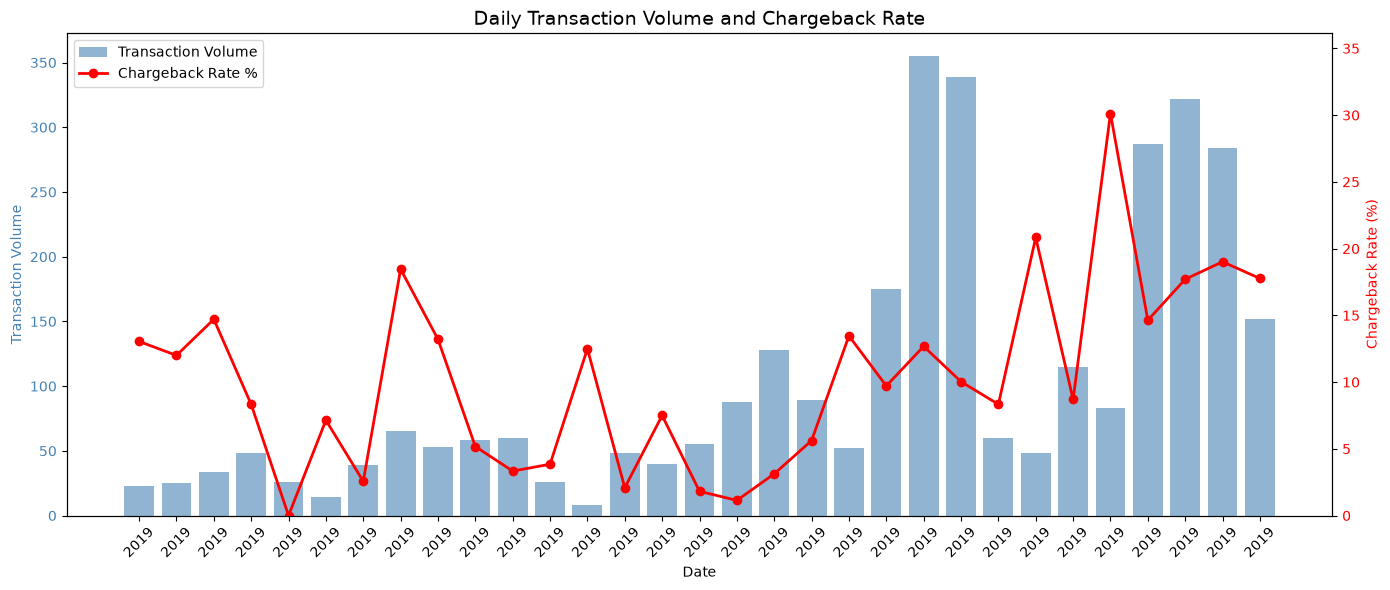

In [558]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['date'] = df['transaction_date'].dt.date
df['hour'] = df['transaction_date'].dt.hour
df['day_of_week'] = df['transaction_date'].dt.day_name()

daily = df.groupby('date').agg(
    total_volume=('transaction_amount', 'count'),
    total_amount=('transaction_amount', 'sum'),
    cbk_count=('has_cbk', 'sum'),
    cbk_rate=('has_cbk', 'mean')
).reset_index()

daily['cbk_rate_pct'] = daily['cbk_rate'] * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for volume
ax1.bar(daily['date'], daily['total_volume'], color='steelblue', alpha=0.6, label='Transaction Volume')
ax1.set_xlabel('Date')
ax1.set_ylabel('Transaction Volume', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(daily['date'][::max(1, len(daily)//20)])
ax1.tick_params(axis='x', rotation=45)

# Line chart for chargeback rate (on secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['cbk_rate_pct'], color='red', marker='o', linewidth=2, label='Chargeback Rate %')
ax2.set_ylabel('Chargeback Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(10, daily['cbk_rate_pct'].max() * 1.2))  # Cap at 10% or 1.2x max

# Title and legend
plt.title('Daily Transaction Volume and Chargeback Rate', fontsize=14)
fig.tight_layout()

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

### 2. Hour-of-day and day-of-week patterns

In [559]:
df_transactions_in_each_hour= df.groupby('hour')['has_cbk'].agg(Transactions_in_each_hour = 'count', CBK_rate_in_each_hour = 'mean').reset_index()
df_transactions_in_each_day_of_week= df.groupby('day_of_week')['has_cbk'].agg(Transactions_in_each_day_of_week = 'count', CBK_rate_in_each_day_of_week = 'mean').reset_index()
print(f'Rate of CBK in each hour of the day:\n{df_transactions_in_each_hour}\nRate of CBK in each day of the week:\n{df_transactions_in_each_day_of_week}')

Rate of CBK in each hour of the day:
    hour  Transactions_in_each_hour  CBK_rate_in_each_hour
0      0                        133                   0.18
1      1                        111                   0.13
2      2                         61                   0.30
3      3                         30                   0.13
4      4                          7                   0.00
5      5                          4                   0.00
6      6                          2                   0.50
7      8                          3                   0.00
8      9                          7                   0.00
9     10                         29                   0.00
10    11                         93                   0.05
11    12                        111                   0.08
12    13                        195                   0.06
13    14                        247                   0.06
14    15                        239                   0.08
15    16           

### 3. Velocity: time between transactions per entity

In [560]:
df = df.sort_values(['user_id', 'transaction_date'])
df['time_since_last_txn_user_id'] = df.groupby('user_id')['transaction_date'].diff()
df['time_since_last_txn_card_number'] = df.groupby('card_number')['transaction_date'].diff()
df['time_since_last_txn_device_id'] = df.groupby('device_id')['transaction_date'].diff()
df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,date,hour,day_of_week,time_since_last_txn_user_id,time_since_last_txn_card_number,time_since_last_txn_device_id
11,21320409,32954,6,428267******9019,2019-12-01 20:44:48.109011,443.90,757451.00,False,2019-12-01,20,Sunday,NaT,NaT,NaT
3197,21323595,35930,7,544315******7773,2019-11-01 01:29:45.799767,359.68,NaN,False,2019-11-01,1,Friday,NaT,NaT,NaT
3198,21323596,17348,8,650487******9884,2019-11-01 01:27:15.811098,2416.70,NaN,False,2019-11-01,1,Friday,NaT,NaT,NaT
3189,21323587,82477,19,525496******3638,2019-11-01 17:52:57.071163,165.14,NaN,False,2019-11-01,17,Friday,NaT,NaT,NaT
390,21320788,64192,132,485464******8785,2019-11-30 10:36:29.122871,714.56,568889.00,False,2019-11-30,10,Saturday,NaT,NaT,NaT


### 4. First-seen vs. established behavior

In [561]:
df['card_first_seen'] = df.groupby('card_number')['transaction_date'].transform('min')
df['card_last_seen'] = df.groupby('card_number')['transaction_date'].transform('max')
df['card_activity_span'] = (df['card_last_seen'] - df['card_first_seen']).dt.total_seconds() / (24 * 3600)

df['user_first_seen'] = df.groupby('user_id')['transaction_date'].transform('min')
df['user_last_seen'] = df.groupby('user_id')['transaction_date'].transform('max')
df['user_activity_span'] = (df['user_last_seen'] - df['user_first_seen']).dt.total_seconds() / (24 * 3600)

df['device_first_seen'] = df.groupby('device_id')['transaction_date'].transform('min')
df['device_last_seen'] = df.groupby('device_id')['transaction_date'].transform('max')
df['device_activity_span'] = (df['device_last_seen'] - df['device_first_seen']).dt.total_seconds() / (24 * 3600)

df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,date,hour,day_of_week,time_since_last_txn_user_id,time_since_last_txn_card_number,time_since_last_txn_device_id,card_first_seen,card_last_seen,card_activity_span,user_first_seen,user_last_seen,user_activity_span,device_first_seen,device_last_seen,device_activity_span
11,21320409,32954,6,428267******9019,2019-12-01 20:44:48.109011,443.90,757451.00,False,2019-12-01,20,Sunday,NaT,NaT,NaT,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00
3197,21323595,35930,7,544315******7773,2019-11-01 01:29:45.799767,359.68,NaN,False,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,NaT,NaT,NaN
3198,21323596,17348,8,650487******9884,2019-11-01 01:27:15.811098,2416.70,NaN,False,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,NaT,NaT,NaN
3189,21323587,82477,19,525496******3638,2019-11-01 17:52:57.071163,165.14,NaN,False,2019-11-01,17,Friday,NaT,NaT,NaT,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,NaT,NaT,NaN
390,21320788,64192,132,485464******8785,2019-11-30 10:36:29.122871,714.56,568889.00,False,2019-11-30,10,Saturday,NaT,NaT,NaT,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00


## 5. Cross-entity relationships

### 1. Device shared across multiple users

In [562]:
df['device_users'] = df.groupby('device_id')['user_id'].transform('nunique')
if df[df['device_users'] > 1].empty:
    print('There is no devices with more than one user.')
else:
    print(df[df['device_users'] > 1])
    

There is no devices with more than one user.


### 2. Card used across multiple devices

In [563]:
df['card_devices'] = df.groupby('card_number')['device_id'].transform('nunique')
if df[df['card_devices'] > 1].empty:
    print('There is no cards used across multiple devices.')
else:
     print(df[df['card_devices'] > 1].head())


      transaction_id  merchant_id  user_id       card_number           transaction_date  transaction_amount  device_id  has_cbk        date  hour day_of_week time_since_last_txn_user_id time_since_last_txn_card_number time_since_last_txn_device_id            card_first_seen             card_last_seen  card_activity_span            user_first_seen             user_last_seen  user_activity_span          device_first_seen           device_last_seen  device_activity_span  device_users  card_devices
1800        21322198        53041      900  412177******1138 2019-11-22 19:15:41.109970             1346.26  691601.00     True  2019-11-22    19      Friday                         NaT                             NaT                           NaT 2019-11-22 19:15:41.109970 2019-11-26 14:11:59.129077                3.79 2019-11-22 19:15:41.109970 2019-11-22 19:15:41.109970                0.00 2019-11-22 19:15:41.109970 2019-11-22 19:15:41.109970                  0.00          1.00             2


### 3. Card used across multiple users

In [564]:
df['card_users'] = df.groupby('card_number')['user_id'].transform('nunique')
if df[df['card_users'] > 1].empty:
    print('There is no cards with multiple users.')
else:
     print(df[df['card_users'] > 1].head())

      transaction_id  merchant_id  user_id       card_number           transaction_date  transaction_amount  device_id  has_cbk        date  hour day_of_week time_since_last_txn_user_id time_since_last_txn_card_number time_since_last_txn_device_id            card_first_seen             card_last_seen  card_activity_span            user_first_seen             user_last_seen  user_activity_span          device_first_seen           device_last_seen  device_activity_span  device_users  card_devices  card_users
1800        21322198        53041      900  412177******1138 2019-11-22 19:15:41.109970             1346.26  691601.00     True  2019-11-22    19      Friday                         NaT                             NaT                           NaT 2019-11-22 19:15:41.109970 2019-11-26 14:11:59.129077                3.79 2019-11-22 19:15:41.109970 2019-11-22 19:15:41.109970                0.00 2019-11-22 19:15:41.109970 2019-11-22 19:15:41.109970                  0.00          1.00   

### 4. User with multiple cards

In [565]:
df['user_cards'] = df.groupby('user_id')['card_number'].transform('nunique')
if df[df['user_cards'] > 1].empty:
    print('There is no users with multiple cards.')
else:
     print(df[df['user_cards'] > 1].head())

      transaction_id  merchant_id  user_id       card_number           transaction_date  transaction_amount  device_id  has_cbk        date  hour day_of_week time_since_last_txn_user_id time_since_last_txn_card_number time_since_last_txn_device_id            card_first_seen             card_last_seen  card_activity_span            user_first_seen             user_last_seen  user_activity_span          device_first_seen           device_last_seen  device_activity_span  device_users  card_devices  card_users  user_cards
2520        21322918        42687     1516  423153******7295 2019-11-17 18:19:35.440542             1354.65  167508.00    False  2019-11-17    18      Sunday                         NaT                             NaT                           NaT 2019-11-17 18:19:35.440542 2019-11-17 18:19:35.440542                0.00 2019-11-17 18:19:35.440542 2019-11-19 15:41:47.368499                1.89 2019-11-17 18:19:35.440542 2019-11-19 15:41:47.368499                  1.89     

### 5. Simple "entity graph" view

Graph: 200 nodes, 117 edges
Node types: Counter({'user': 89, 'device': 77, 'card': 34})

🔍 Suspicious clusters found: 27


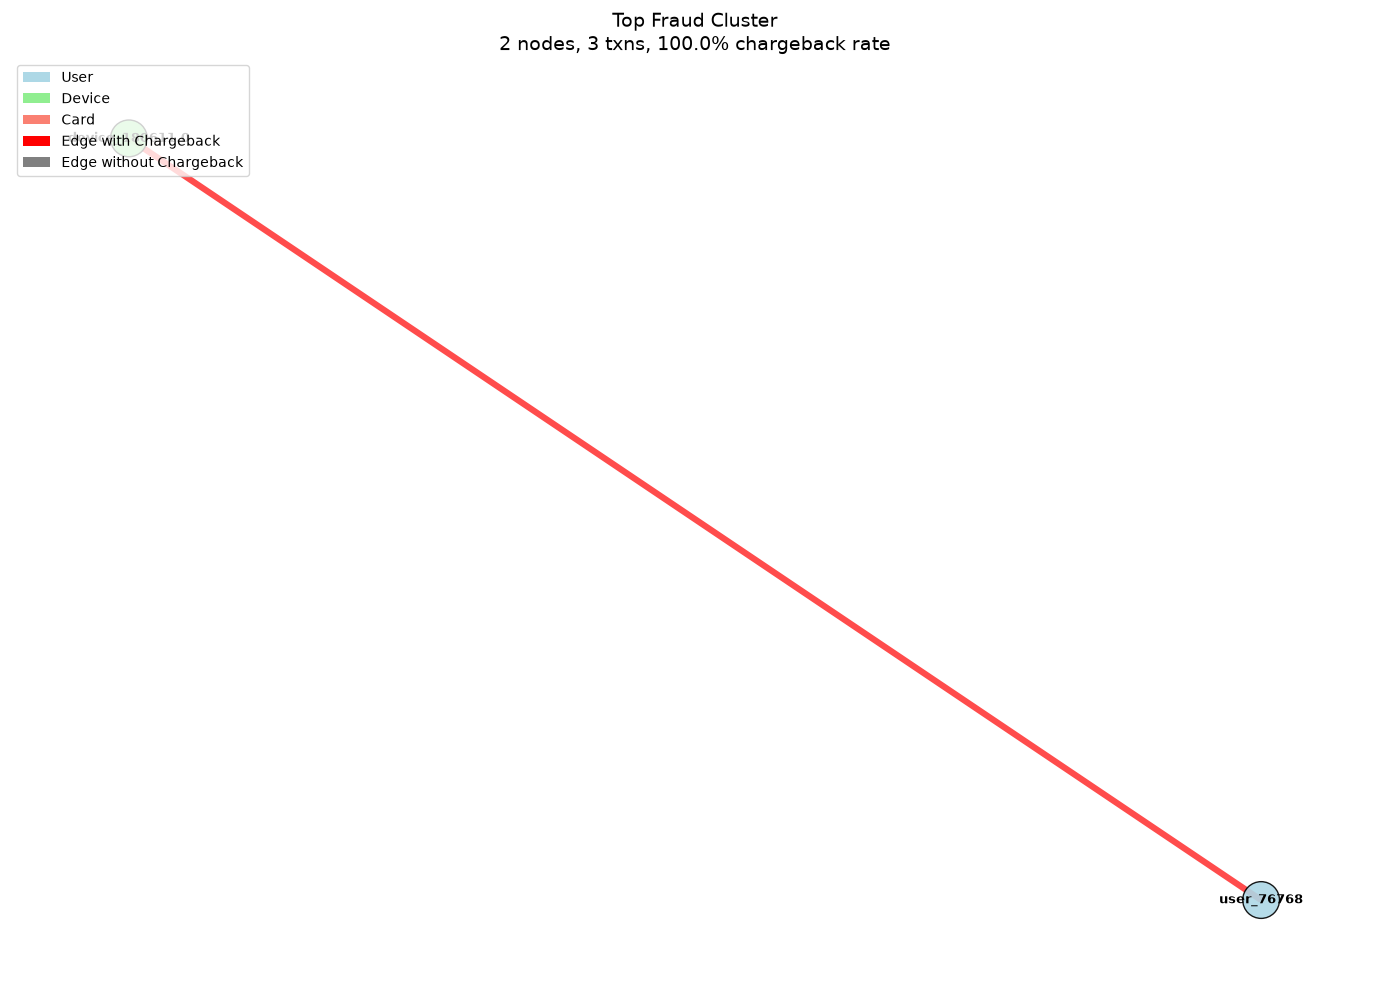


=== Top Cluster Edges ===
device_180611.0 ↔ user_76768: 3 txns, CBK: 3, Avg: $3370.06


In [566]:
import networkx as nx
from collections import Counter
from matplotlib.patches import Patch

# =============================================
# 1. Prepare data
# =============================================
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df = df.dropna(subset=['transaction_date'])

# Ensure has_cbk is numeric (0/1)
if 'has_cbk' in df.columns:
    df['has_cbk'] = df['has_cbk'].astype(int)

# =============================================
# 2. Build graph from transactions
# =============================================
entity_cols = [
    ('user_id', 'user'),
    ('device_id', 'device'),
    ('card_number', 'card')
]

def build_graph(df, entity_cols, max_nodes=200):
    G = nx.Graph()
    for _, row in df.iterrows():
        entities = []
        for col, ntype in entity_cols:
            val = row.get(col)
            if pd.notna(val):
                entities.append((f"{ntype}_{val}", ntype))
        if len(entities) < 2:
            continue
        for i in range(len(entities)):
            for j in range(i + 1, len(entities)):
                u, ut = entities[i]
                v, vt = entities[j]
                G.add_node(u, type=ut)
                G.add_node(v, type=vt)
                if G.has_edge(u, v):
                    G[u][v]['count'] += 1
                    G[u][v]['transactions'].append(row['transaction_id'])
                    G[u][v]['amounts'].append(row['transaction_amount'])
                    G[u][v]['has_cbk'].append(row['has_cbk'])
                else:
                    G.add_edge(u, v,
                               count=1,
                               transactions=[row['transaction_id']],
                               amounts=[row['transaction_amount']],
                               has_cbk=[row['has_cbk']])
    if max_nodes and len(G.nodes) > max_nodes:
        degrees = dict(G.degree())
        top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:max_nodes]
        G = G.subgraph(top_nodes).copy()
    return G

G = build_graph(df, entity_cols, max_nodes=200)
print(f"Graph: {len(G.nodes)} nodes, {len(G.edges)} edges")
print("Node types:", Counter(nx.get_node_attributes(G, 'type').values()))

# =============================================
# 3. Find suspicious clusters
# =============================================
clusters = []
for comp in nx.connected_components(G):
    sub = G.subgraph(comp)
    total = sum(data['count'] for _, _, data in sub.edges(data=True))
    cbk = sum(sum(data['has_cbk']) for _, _, data in sub.edges(data=True))
    rate = cbk / total if total > 0 else 0
    if total >= 3 and rate >= 0.3:
        clusters.append({'nodes': list(comp), 'total': total, 'cbk': cbk, 'rate': rate, 'sub': sub})

clusters.sort(key=lambda x: x['rate'], reverse=True)
print(f"\n🔍 Suspicious clusters found: {len(clusters)}")

# =============================================
# 4. Visualize the top cluster
# =============================================
if clusters:
    top = clusters[0]
    sub = top['sub']
    
    # Colors
    color_map = {'user': 'lightblue', 'device': 'lightgreen', 'card': 'salmon'}
    node_colors = [color_map[sub.nodes[n]['type']] for n in sub.nodes]
    edge_colors = ['red' if sum(data['has_cbk']) > 0 else 'gray' for _, _, data in sub.edges(data=True)]
    edge_widths = [data['count'] * 1.5 for _, _, data in sub.edges(data=True)]
    node_sizes = [sub.degree(n) * 300 + 400 for n in sub.nodes]
    
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(sub, k=2, seed=42)
    nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors='black')
    nx.draw_networkx_edges(sub, pos, edge_color=edge_colors, width=edge_widths, alpha=0.7)
    nx.draw_networkx_labels(sub, pos, font_size=9, font_weight='bold')
    
    legend = [Patch(facecolor='lightblue', label='User'), Patch(facecolor='lightgreen', label='Device'),
              Patch(facecolor='salmon', label='Card'), Patch(facecolor='red', label='Edge with Chargeback'),
              Patch(facecolor='gray', label='Edge without Chargeback')]
    plt.legend(handles=legend, loc='upper left')
    plt.title(f"Top Fraud Cluster\n{len(sub.nodes)} nodes, {top['total']} txns, {top['rate']:.1%} chargeback rate", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("\n=== Top Cluster Edges ===")
    for u, v, data in sub.edges(data=True):
        print(f"{u} ↔ {v}: {data['count']} txns, CBK: {sum(data['has_cbk'])}, "
              f"Avg: ${sum(data['amounts'])/len(data['amounts']):.2f}")
else:
    print("✅ No suspicious clusters with the current thresholds.")
    print("💡 Try adjusting: min_edges=2 or min_cbk_rate=0.2")

## 6. Merchant-level analysis

### 1. Chargeback rate per merchant

In [567]:
df['merchant_volume_transactions'] = df.groupby('merchant_id')['has_cbk'].transform('count')
df['merchant_CBK_rate'] = df.groupby('merchant_id')['has_cbk'].transform('mean')

df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,date,hour,day_of_week,time_since_last_txn_user_id,time_since_last_txn_card_number,time_since_last_txn_device_id,card_first_seen,card_last_seen,card_activity_span,user_first_seen,user_last_seen,user_activity_span,device_first_seen,device_last_seen,device_activity_span,device_users,card_devices,card_users,user_cards,merchant_volume_transactions,merchant_CBK_rate
11,21320409,32954,6,428267******9019,2019-12-01 20:44:48.109011,443.90,757451.00,0,2019-12-01,20,Sunday,NaT,NaT,NaT,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,1.00,1,1,1,1,0.00
3197,21323595,35930,7,544315******7773,2019-11-01 01:29:45.799767,359.68,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,NaT,NaT,NaN,NaN,0,1,1,3,0.00
3198,21323596,17348,8,650487******9884,2019-11-01 01:27:15.811098,2416.70,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,NaT,NaT,NaN,NaN,0,1,1,16,0.00
3189,21323587,82477,19,525496******3638,2019-11-01 17:52:57.071163,165.14,NaN,0,2019-11-01,17,Friday,NaT,NaT,NaT,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,NaT,NaT,NaN,NaN,0,1,1,4,0.00
390,21320788,64192,132,485464******8785,2019-11-30 10:36:29.122871,714.56,568889.00,0,2019-11-30,10,Saturday,NaT,NaT,NaT,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,1.00,1,1,1,1,0.00


### 2. Volume and average ticket size per merchant

In [568]:
df['merchant_avg_amount'] = df.groupby('merchant_id')['transaction_amount'].transform('mean')
df['merchant_median_amount'] = df.groupby('merchant_id')['transaction_amount'].transform('median')
df['merchant_sum_amount'] = df.groupby('merchant_id')['transaction_amount'].transform('sum')

df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,date,hour,day_of_week,time_since_last_txn_user_id,time_since_last_txn_card_number,time_since_last_txn_device_id,card_first_seen,card_last_seen,card_activity_span,user_first_seen,user_last_seen,user_activity_span,device_first_seen,device_last_seen,device_activity_span,device_users,card_devices,card_users,user_cards,merchant_volume_transactions,merchant_CBK_rate,merchant_avg_amount,merchant_median_amount,merchant_sum_amount
11,21320409,32954,6,428267******9019,2019-12-01 20:44:48.109011,443.90,757451.00,0,2019-12-01,20,Sunday,NaT,NaT,NaT,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,1.00,1,1,1,1,0.00,443.90,443.90,443.90
3197,21323595,35930,7,544315******7773,2019-11-01 01:29:45.799767,359.68,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,NaT,NaT,NaN,NaN,0,1,1,3,0.00,494.62,359.68,1483.86
3198,21323596,17348,8,650487******9884,2019-11-01 01:27:15.811098,2416.70,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,NaT,NaT,NaN,NaN,0,1,1,16,0.00,2031.45,2261.32,32503.23
3189,21323587,82477,19,525496******3638,2019-11-01 17:52:57.071163,165.14,NaN,0,2019-11-01,17,Friday,NaT,NaT,NaT,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,NaT,NaT,NaN,NaN,0,1,1,4,0.00,311.57,259.77,1246.28
390,21320788,64192,132,485464******8785,2019-11-30 10:36:29.122871,714.56,568889.00,0,2019-11-30,10,Saturday,NaT,NaT,NaT,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,1.00,1,1,1,1,0.00,714.56,714.56,714.56


### 3. Cross merchant with your entity-relationship findings

In [569]:
suspicious_device_id = 180611.0 # # Found in section 5.5 of this notebook

df[df['device_id'] == suspicious_device_id]['merchant_id'].value_counts()


merchant_id
18344    2
54603    1
Name: count, dtype: int64

### 4. Merchant diversity per suspicious entity 

In [570]:
merchant_diversity_device_id = df.groupby('device_id')['merchant_id'].nunique().rename('merchant_per_supicious_device_id').sort_values(ascending=False).reset_index()
merchant_diversity_device_id[merchant_diversity_device_id['device_id'] == suspicious_device_id]

,device_id,merchant_per_supicious_device_id
15,180611.00,2


### 5. New vs. established merchants

In [571]:
df['merchant_first_appearance'] = df.groupby('merchant_id')['date'].transform('min')
df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,date,hour,day_of_week,time_since_last_txn_user_id,time_since_last_txn_card_number,time_since_last_txn_device_id,card_first_seen,card_last_seen,card_activity_span,user_first_seen,user_last_seen,user_activity_span,device_first_seen,device_last_seen,device_activity_span,device_users,card_devices,card_users,user_cards,merchant_volume_transactions,merchant_CBK_rate,merchant_avg_amount,merchant_median_amount,merchant_sum_amount,merchant_first_appearance
11,21320409,32954,6,428267******9019,2019-12-01 20:44:48.109011,443.90,757451.00,0,2019-12-01,20,Sunday,NaT,NaT,NaT,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,2019-12-01 20:44:48.109011,2019-12-01 20:44:48.109011,0.00,1.00,1,1,1,1,0.00,443.90,443.90,443.90,2019-12-01
3197,21323595,35930,7,544315******7773,2019-11-01 01:29:45.799767,359.68,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,NaT,NaT,NaN,NaN,0,1,1,3,0.00,494.62,359.68,1483.86,2019-11-01
3198,21323596,17348,8,650487******9884,2019-11-01 01:27:15.811098,2416.70,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,NaT,NaT,NaN,NaN,0,1,1,16,0.00,2031.45,2261.32,32503.23,2019-11-01
3189,21323587,82477,19,525496******3638,2019-11-01 17:52:57.071163,165.14,NaN,0,2019-11-01,17,Friday,NaT,NaT,NaT,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,2019-11-01 17:52:57.071163,2019-11-01 17:52:57.071163,0.00,NaT,NaT,NaN,NaN,0,1,1,4,0.00,311.57,259.77,1246.28,2019-11-01
390,21320788,64192,132,485464******8785,2019-11-30 10:36:29.122871,714.56,568889.00,0,2019-11-30,10,Saturday,NaT,NaT,NaT,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,2019-11-30 10:36:29.122871,2019-11-30 10:36:29.122871,0.00,1.00,1,1,1,1,0.00,714.56,714.56,714.56,2019-11-30


## 7. Behavioral/velocity features (Creating a feature store to feed into a ML model)

### 1. Rolling transaction count (velocity) per entity

In [572]:
fs_transactional_data = df.copy().sort_values('transaction_date')

fs_transactional_data = fs_transactional_data.set_index('transaction_date')

for i in ['user_id', 'card_number', 'device_id']:
    for j in ['1h','24h','7D']:

        col_name = f'txn_count_{j}_{i}'
        fs_transactional_data[col_name] = (
            fs_transactional_data.groupby(i)['transaction_id']
            .rolling(j)
            .count()
            .reset_index(level=0, drop=True) 
        )

fs_transactional_data = fs_transactional_data.reset_index()

fs_transactional_data.head()

,transaction_date,transaction_id,merchant_id,user_id,card_number,transaction_amount,device_id,has_cbk,date,hour,day_of_week,time_since_last_txn_user_id,time_since_last_txn_card_number,time_since_last_txn_device_id,card_first_seen,card_last_seen,card_activity_span,user_first_seen,user_last_seen,user_activity_span,device_first_seen,device_last_seen,device_activity_span,device_users,card_devices,card_users,user_cards,merchant_volume_transactions,merchant_CBK_rate,merchant_avg_amount,merchant_median_amount,merchant_sum_amount,merchant_first_appearance,txn_count_1h_user_id,txn_count_24h_user_id,txn_count_7D_user_id,txn_count_1h_card_number,txn_count_24h_card_number,txn_count_7D_card_number,txn_count_1h_device_id,txn_count_24h_device_id,txn_count_7D_device_id
0,2019-11-01 01:27:15.811098,21323596,17348,8,650487******9884,2416.70,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,2019-11-01 01:27:15.811098,2019-11-01 01:27:15.811098,0.00,NaT,NaT,NaN,NaN,0,1,1,16,0.00,2031.45,2261.32,32503.23,2019-11-01,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN
1,2019-11-01 01:29:45.799767,21323595,35930,7,544315******7773,359.68,NaN,0,2019-11-01,1,Friday,NaT,NaT,NaT,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,2019-11-01 01:29:45.799767,2019-11-01 01:29:45.799767,0.00,NaT,NaT,NaN,NaN,0,1,1,3,0.00,494.62,359.68,1483.86,2019-11-01,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN
2,2019-11-01 10:23:50.555604,21323594,57997,84486,522688******9874,1.55,NaN,0,2019-11-01,10,Friday,NaT,NaT,NaT,2019-11-01 10:23:50.555604,2019-11-18 14:39:31.744189,17.18,2019-11-01 10:23:50.555604,2019-11-18 14:39:31.744189,17.18,NaT,NaT,NaN,NaN,0,1,1,3,0.00,1.56,1.55,4.69,2019-11-01,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN
3,2019-11-01 11:47:02.404963,21323593,9603,59275,528052******3611,1403.67,NaN,0,2019-11-01,11,Friday,NaT,NaT,NaT,2019-11-01 11:47:02.404963,2019-11-01 11:47:02.404963,0.00,2019-11-01 11:47:02.404963,2019-11-01 11:47:02.404963,0.00,NaT,NaT,NaN,NaN,0,1,1,1,0.00,1403.67,1403.67,1403.67,2019-11-01,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN
4,2019-11-01 13:05:34.054967,21323592,50493,49581,650486******4139,744.15,NaN,0,2019-11-01,13,Friday,NaT,NaT,NaT,2019-11-01 13:05:34.054967,2019-11-01 13:05:34.054967,0.00,2019-11-01 13:05:34.054967,2019-11-01 13:05:34.054967,0.00,NaT,NaT,NaN,NaN,0,1,1,4,0.00,724.84,725.59,2899.37,2019-11-01,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN


### 2. Distinct-entity counts in a trailing window